In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("thyroid_dataset.csv")


In [6]:
X = df.drop("Outlier_label" , axis= 1)
y = df["Outlier_label"]

In [7]:
scaler = StandardScaler()

In [8]:
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators = 200 , contamination = 'auto' , random_state = 42)

In [10]:
labels = clf.fit_predict(X_scaled)

In [13]:
#Visualize
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PCA2')

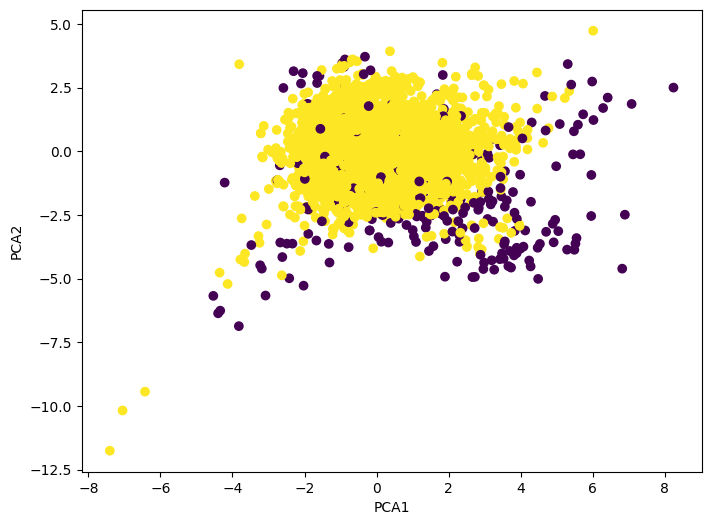

In [14]:
plt.figure(figsize = (8 , 6))

plt.scatter(X_pca[: , 0] , X_pca[: , 1] , c = labels)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

In [15]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print(f"outliers : {n_outliers} & normal : {n_normal}")

outliers : 270 & normal : 6646


LOF

In [16]:
from sklearn.neighbors import LocalOutlierFactor


In [17]:
neighbs = LocalOutlierFactor()

labels = neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

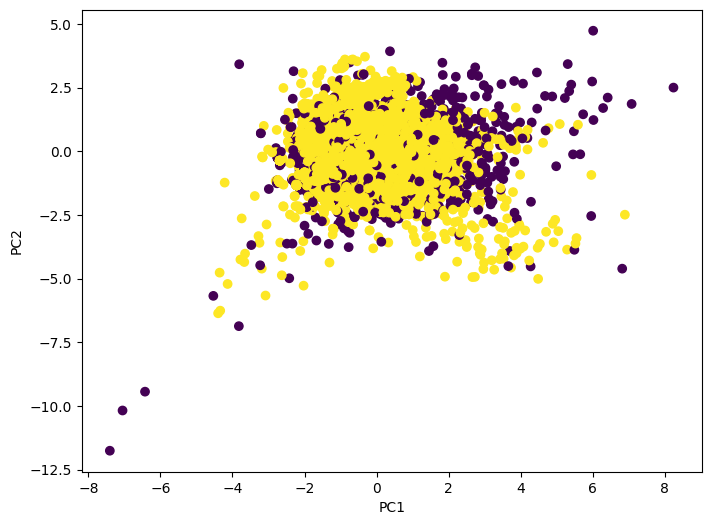

In [18]:
plt.figure(figsize = (8 , 6))

plt.scatter(X_pca[: , 0] , X_pca[: , 1] , c = labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [19]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print(f"outliers : {n_outliers} & normal : {n_normal}")

outliers : 883 & normal : 6033
